

# Домашнее задание №8  (10 баллов).

## Байесовские оценки


### Дедлайн: 14 июня 23:59

#### Требования к практическому домашнему заданию.
1.   Задание выполняется в этом Jupyter Notebook'е.
2.   Код должен быть читаемым, сопровождаться комментариями, а имена переменных должны быть понятными.
3. При построении графиков обязательно должны быть подписаны координатные оси. Если на графике изображено несколько кривых, не забудьте вывести легенду. Легенда не должна закрывать графики.
4. Каждый численный результат и график обязан сопровождаться интерпретацией
5. В теоретических вопросам недостаточно написать только ответ, должен быть предоставлен полный вывод.
6. Обязательно напишите свое ФИО в поле ниже.






```
# Выбран кодовый формат
```

**ФИО**: `Соленникова София Сергеевна`

### Как сдавать
В каждом задании **сначала** письменно ответьте на теоретический вопрос (полный вывод, а не только
ответ) в ячейках с пометкой `[впишите]`, и **только потом** заполняйте код в ячейках с пометкой `# ==== ВАШ КОД ====`.
Перед сдачей: **Kernel → Restart & Run All**.
Рядом должен лежать `baseball.csv`.


## История одного бейсбольного сезона

В апреле 1970 года два статистика — **Брэдли Эфрон** и **Карл Моррис** — открыли воскресную газету,
где печатали таблицы бейсбольной статистики, и выписали оттуда **18 игроков, у каждого из которых
было ровно по 45 подач** в начале сезона. У каждого игрока известна его доля удачных
ударов  по этим первым 45 попыткам. Например, легендарный **Роберто Клементе**
выбил 18 из 45, то есть 0.4. А Тёрмен Мансон — всего 8 из 45, то есть 0.178.

Вопрос, который задали Эфрон и Моррис:

> **Как по первым 45 подачам предсказать, как игрок будет бить весь остаток сезона?**

Наивный ответ: «доля по первым 45 подачам и есть наша оценка». Клементе бьёт 0.4 — значит,
прогноз на сезон 0.4. Мансон бьёт 0.178 — значит, прогноз на сезон 0.178.

 Эфрон и Моррис показали, что этот «очевидный» ответ —
**плохой**. Если вместо индивидуальных оценок **подтянуть** их все к общему среднему по лиге
(сильных — вниз, слабых — вверх), прогноз становится в **3.5 раза точнее** по суммарной
квадратичной ошибке. Клементе на самом деле закончил сезон с 0.346 (не 0.4!), а Мансон —
с 0.316 (совсем не 0.178!). «Подтянутые» к среднему оценки угадали это куда лучше, чем наивные.

Этот результат — один из самых знаменитых в статистике XX века. Он лежит в основе
**оценки Джеймса - Штейна (James–Stein)** и **байесовского сжатия (shrinkage)**.


Интуиция «подтянуть к среднему» — это в точности то, что делает **байесовская оценка**. Если
до эксперимента мы знаем, что *типичный* игрок бьёт около 0.26 (априорное распределение), то
игрок с 0.4 по 45 подачам скорее всего поймал удачную серию, и разумно ожидать от него
поменьше. Чем меньше данных (45 подач — это очень мало), тем сильнее априорное знание тянет
оценку к среднему. Чем больше данных — тем меньше влияние априорного, и оценка стремится к  оценке максимального правдоподобия (ОМП).





## Данные

Используем **реальный** датасет Эфрона–Морриса (1970) `baseball.csv` — те самые 18 игроков:

| столбец | смысл |
|---|---|
| `name`, `team`, `league` | игрок, команда, лига |
| `r` | число удачных ударов (hits) в **первых 45** подачах |
| `y` | доля по первым 45 подачам, $y = r/45$ (это наблюдаемая «ранняя» оценка) |
| `n` | число подач в **остатке** сезона |
| `p` | доля по остатку сезона — **это то, что мы хотим предсказать** (наша «истина» для проверки) |

Идея проверки: оцениваем способность игрока по `r` (первые 45 подач), а качество проверяем по `p`
(весь остаток сезона) — данным, которых модель не видела.



Снова будем использовать статистический модуль `scipy.stats`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

In [3]:
rng = np.random.default_rng(0)
df = pd.read_csv("baseball.csv")
N_AB = 45                      # у всех ровно 45 подач в начале сезона
print("Игроков:", len(df))
df[["name", "r", "y", "p", "n"]].head(6)

Игроков: 18


,name,r,y,p,n
0,Roberto Clemente,18,0.400,0.346,367
1,Frank Robinson,17,0.378,0.298,426
2,Frank Howard,16,0.356,0.276,521
3,Jay Johnstone,15,0.333,0.222,275
4,Ken Berry,14,0.311,0.273,418
5,Jim Spencer,14,0.311,0.270,466


## Часть 0. Знакомство с данными *(0.5 баллов)*

Посмотрим на ключевую картинку: ранние доли `y` и итоговые `p` относительно общего среднего.

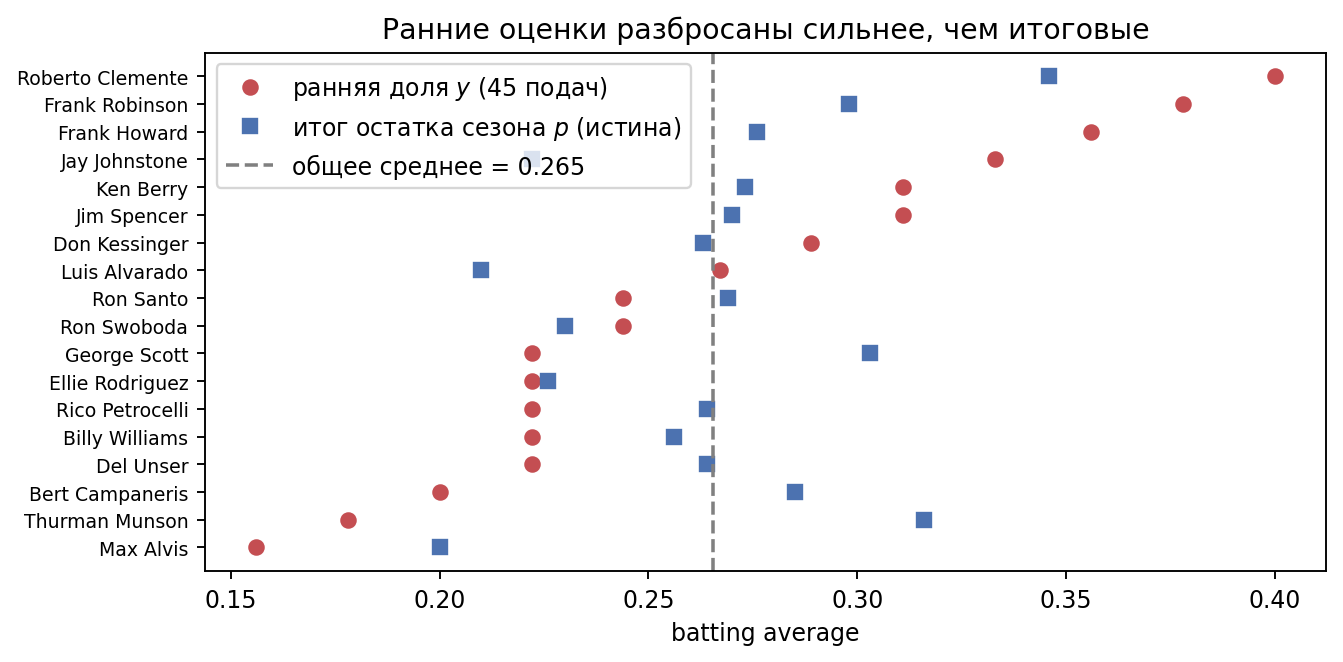

Разброс ранних долей y:  std = 0.070
Разброс итоговых p:      std = 0.038  (заметно меньше!)


In [4]:
ybar = df.y.mean()

fig, ax = plt.subplots(figsize=(8, 4), dpi=170)

order = df.sort_values("y").index

ax.plot(df.y[order], range(len(df)), "o", color="#C44E52", label="ранняя доля $y$ (45 подач)")
ax.plot(df.p[order], range(len(df)), "s", color="#4C72B0", label="итог остатка сезона $p$ (истина)")
ax.axvline(ybar, color="gray", ls="--", label=f"общее среднее = {ybar:.3f}")
ax.set_yticks(range(len(df))); ax.set_yticklabels(df.name[order], fontsize=8)
ax.set_xlabel("batting average"); ax.legend(); ax.set_title("Ранние оценки разбросаны сильнее, чем итоговые")
plt.tight_layout(); plt.show()
print(f"Разброс ранних долей y:  std = {df.y.std():.3f}")
print(f"Разброс итоговых p:      std = {df.p.std():.3f}  (заметно меньше!)")

**Задание 0.1.** *(0.5 баллов)* Сравните разброс красных точек (ранние `y`) и синих (итоговые `p`). Какие из ранних
оценок далеки от среднего? Куда сместилась бо́льшая часть синих точек —
к среднему или от него? Почему это намёк на то, что ранние крайние значения стоит «подтянуть» к среднему?

*Ваш ответ:* `
Красные точки (ранние доли y) имеют гораздо больший разброс, чем синие (итоговые p): красные кружочки раскиданы по картинке, а синие - наоборот кучкуются.

Большая часть синих точек сместилась ближе к среднему значению (линии общего среднего). Те игроки, которые на старте имели экстремально высокие результаты (правая часть графика), к концу сезона показали более низкие результаты, а те, кто имел экстремально низкие (левая часть), подтянулись вверх.

Наблюдаемое явление — это статистическая регрессия к среднему. Крайние значения на выборке из 45 попыток с высокой вероятностью обусловлены не только реальным мастерством игрока, но и значительным влиянием случайности (удачей или неудачей). Поскольку мы ожидаем, что в долгосрочной перспективе (на дистанции остатка сезона) фактор случайности усредняется, крайние значения возвращаются к среднему по популяции.
`

## Часть 1. Байесовская оценка  *(2 балла)*
Для одного игрока: число удачных ударов
$r$ из $n=45$ подач — это

$$r \sim \mathrm{Bin}(n, \theta),$$

где $\theta \in (0,1)$ — «истинная» способность
игрока. В качестве   априорного распределения выбираем бета-распределение
с точно таким же носителем $\theta \in (0,1)$

 $$\theta \sim \mathrm{Beta}(\alpha, \beta),$$

где  $\alpha, \beta>0$ - известные константы.



**Задание 1.1.** *(1.5 балл)*
Пусть $X_1, \dots X_n$ - выборка из распределения Бернулли. Тогда $r = \sum\limits_{i=1}^n X_i \sim \mathrm{Bin}(n, \theta)$,  $\theta \sim \mathrm{Beta}(\alpha, \beta)$.

1. Покажите, что апостериорное распределение - это бета-распределение:

 $$\theta \mid r \sim \mathrm{Beta}(\alpha + r,\ \beta + n - r).$$

2. Покажите, что **байесовская оценка**  при **квадратичной** функции потерь
есть
$$\widehat\theta_\pi = \mathbb E[\theta \mid r] = \frac{\alpha + r}{\alpha + \beta + n}.$$

3. Покажите, что её можно записать как **взвешенное среднее**  ОМП $\overline X$ и априорного среднего $\dfrac{\alpha}{\alpha+\beta}$:

$$\widehat\theta_\pi =  (1- w)\cdot\overline X + w\cdot\frac{\alpha}{\alpha+\beta} .$$

Чему равен вес $w$? Как он ведёт себя при $n\to\infty$ (много данных) и при $n\to 0$ (мало данных)? Это и есть формальное «сжатие к среднему».

*Ваш вывод:* `[впишите полный вывод]`

In [5]:
# 1.1 Байесовская оценка (апостериорное среднее) для Beta(alpha,beta) prior

def bayes_estimate(r, n, alpha, beta):
    """Возвращает апостериорное среднее"""

    # ==== ВАШ КОД ====

    return (alpha + r) / (alpha + beta + n)
    # =================

def shrinkage_weight(n, alpha, beta):

    """Вес w при априорном среднем"""

    # ==== ВАШ КОД ====

    return (alpha + beta) / (n + alpha + beta)
    # =================

# проверка на Клементе с «плоским» априорным Beta(1,1)

r_clem = int(df.loc[0, "r"])

print(f"Клементе: r={r_clem}/45, ОМП = {r_clem/45:.3f}")
print(f"Байесовская оценка с Beta(1,1): {bayes_estimate(r_clem, 45, 1, 1):.3f}, вес априорного w={shrinkage_weight(45,1,1):.3f}")

Клементе: r=18/45, ОМП = 0.400
Байесовская оценка с Beta(1,1): 0.404, вес априорного w=0.043


**Задание 1.2.**  *(0.5 баллов)* С плоским априорным распределением $\mathrm{Beta}(1,1)$ оценка почти не отличается от ОМП —
почему? (посмотрите на вес $w$ при $\alpha+\beta=2$ и $n=45$). Что нужно сделать с априорным,
чтобы оно сильнее «подтягивало» к среднему? Ниже код для построения плотности бета-распределения.

*Ваш вывод:* `[впишите]`

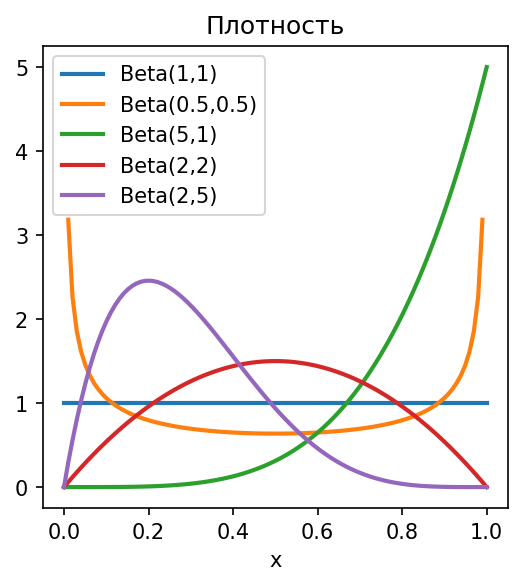

In [6]:
"""Плотность бета-распределения"""

# Define the parameters for the beta distribution
params = [
    (1, 1),  # alpha = 1, beta = 1
    (0.5, 0.5),  # alpha = 2, beta = 1
    (5, 1),  # alpha = 2, beta = 2
    (2, 2),  # alpha = 2, beta = 2
    (2, 5),  # alpha = 2, beta = 0.5
]

# Create an array of x values
x = np.linspace(0, 1, 100)

# Plot the PDF for each parameter set
plt.figure(figsize=(4, 4), dpi = 150)
for alpha, beta in params:
    plt.plot(x, stats.beta.pdf(x, a = alpha, b = beta), label=f'Beta({alpha},{beta})', linewidth=2)

# Add labels and title
plt.title('Плотность')
plt.xlabel('x')
# plt.ylabel('Density')
plt.legend()
plt.show()

## Часть 2. Главный результат Эфрона–Морриса: байесовская оценка лучше наивной оценки максимального правдоподобия *(2 балла)*

Плоское априорное почти не помогает. Сила байесовской статистики — в **содержательном** априорном: мы знаем, что
типичный игрок бьёт около 0.26, и сильные отклонения по 45 подачам скорее всего частично
случайны.

Вспомним:
$$\widehat\theta_\pi = \frac{\alpha + r}{\alpha + \beta + n}.$$

Посмотрим на структуру: в числителе к реальным удачным ударам
r прибавляется $\alpha$, а в знаменателе к реальному числу подач
n прибавляется $\alpha + \beta$. То есть формула выглядит так, как будто игрок до начала эксперимента уже сыграл некоторый «воображаемый» сезон: провёл $\alpha + \beta$ подач, из которых $\alpha$
были удачными, а $\beta$
 — неудачными.
Поэтому $\alpha+\beta$
называют силой (или «эквивалентным размером выборки», pseudo-counts) априорного: это число фиктивных наблюдений, которое априорное «вносит» в оценку наравне с реальными данными.

 Зададим априорное $\mathrm{Beta}(\alpha,\beta)$ так, чтобы:
априорное среднее  $\dfrac{\alpha}{\alpha+\beta}$ равнялось общему среднему по лиге $\bar y$, а «сила» $\alpha+\beta$ управляла степенью сжатия:

 * Большая сила ($\alpha+\beta \gg n$): априорное «весит» больше, чем реальные данные. Оценка почти не отходит от априорного среднего — сильное сжатие. Скажем, при $\alpha+\beta = 90$ и $n = 45$
 априорное «стоит» вдвое больше, чем реальные 45 подач, поэтому оценка тянется к среднему по лиге.
*  Малая сила ($\alpha+\beta \ll n$
): априорное почти ничего не весит, оценка $\approx r/n$
(ОМП). Например, $\mathrm{Beta}(1,1)$
 имеет силу $\alpha+\beta = 2$
 — всего «2 псевдоподачи» против реальных 45, поэтому оно почти не влияет.



**Задание 2.1.** *(0.5 балл)*

Пусть априорное среднее  $m=\dfrac{\alpha}{\alpha+\beta}$ и сила $\kappa=\alpha+\beta$. Выразите
$\alpha$ и $\beta$ через $m$ и $\kappa$. Подставьте в формулу байесовской оценки из 1.1 и убедитесь,
что она принимает вид
$$\widehat\theta_\pi = \frac{\kappa\,m + r}{\kappa + n}.$$
Сила $\kappa$ играет роль «числа псевдонаблюдений» априорного. Что происходит с оценкой
при $\kappa\to 0$ и при $\kappa\to\infty$?

*Ваш вывод:* `[впишите]`

In [7]:
# 2.1 Перепараметризация (m, kappa) -> (alpha, beta) и байесовская оценка через (m, kappa)

def mk_to_ab(m, kappa):
    """Возвращает (alpha, beta) по среднему m и силе kappa."""

    # ==== ВАШ КОД ====

    alpha = kappa * m
    beta = kappa * (1 - m)
    return alpha, beta

    # =================

# зададим априорное: среднее = общее среднее по лиге, силу kappa подберём

m_prior = df.y.mean()
KAPPA = 90.0                     # «90 псевдоподач» — мы вернёмся к выбору kappa в Части 3

alpha0, beta0 = mk_to_ab(m_prior, KAPPA)
print(f"Априорное: m={m_prior:.3f}, kappa={KAPPA}  ->  Beta(alpha={alpha0:.2f}, beta={beta0:.2f})")

# применим ко всем игрокам
df["bayes"] = bayes_estimate(df.r.values, N_AB, alpha0, beta0)
print(df[["name","y","bayes","p"]].head(6).to_string(index=False))

Априорное: m=0.265, kappa=90.0  ->  Beta(alpha=23.88, beta=66.11)
            name     y    bayes     p
Roberto Clemente 0.400 0.310259 0.346
  Frank Robinson 0.378 0.302852 0.298
    Frank Howard 0.356 0.295444 0.276
   Jay Johnstone 0.333 0.288037 0.222
       Ken Berry 0.311 0.280630 0.273
     Jim Spencer 0.311 0.280630 0.270


**Задание 2.2.** *(0.5 баллов)*
Сравните, кто лучше предсказывает итог сезона `p` — наивная оценка `y` или байесовская `bayes`.
Метрика: сумма квадратов ошибок (SSE) относительно `p`.

In [11]:
# 2.2 Сравнение качества прогноза: SSE наивной vs байесовской оценки

y = df.y.values; p = df.p.values; bayes = df.bayes.values

# ==== ВАШ КОД ====

# sse_naive = сумма квадратов (y - p)
sse_naive = np.sum((y - p)**2)

# sse_bayes = сумма квадратов (bayes - p)
sse_bayes = np.sum((p - bayes)**2)

# напечатайте обе и отношение sse_naive/sse_bayes
otnos = sse_naive / sse_bayes

print(f"SSE наивной оценки (ОМП): {sse_naive:.4f}")
print(f"SSE байесовской оценки:   {sse_bayes:.4f}")
print(f"Отношение SSE_naive / SSE_bayes: {otnos:.3f}")

# =================

SSE наивной оценки (ОМП): 0.0754
SSE байесовской оценки:   0.0230
Отношение SSE_naive / SSE_bayes: 3.284


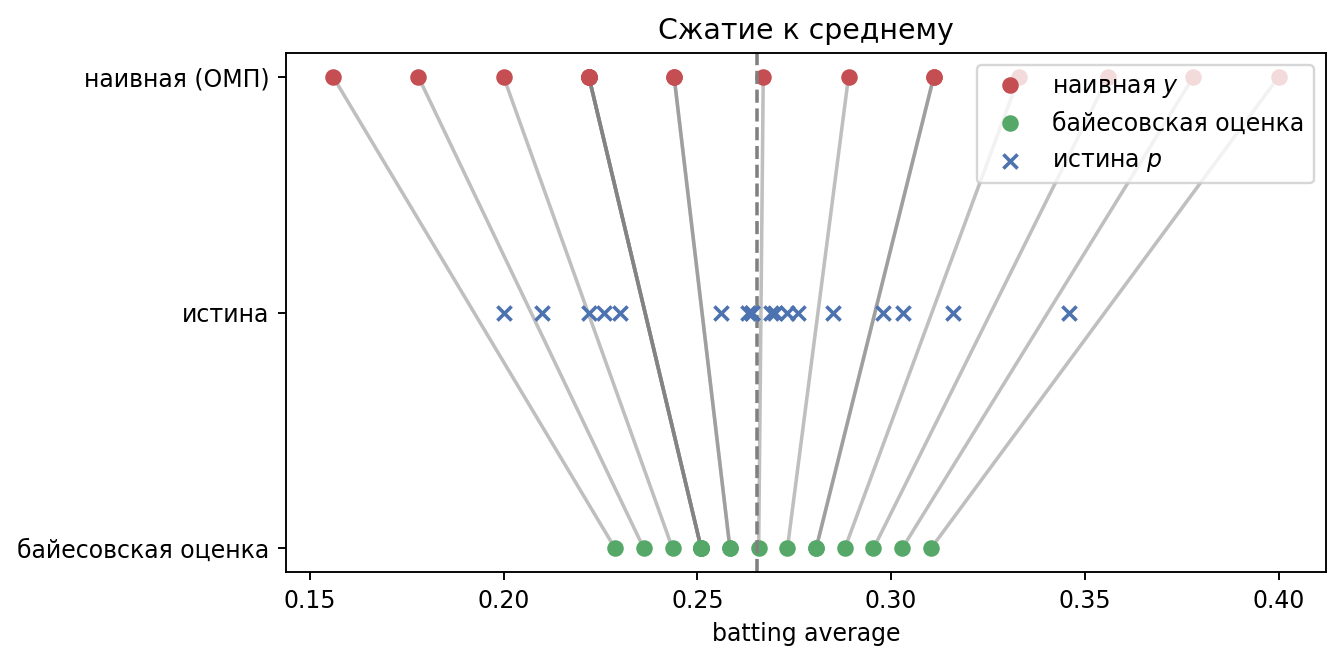

In [12]:
#Картинка сжатия:

fig, ax = plt.subplots(figsize=(8, 4), dpi=170)

for i in range(len(df)):
    ax.plot([df.y[i], df.bayes[i]], [1, 0], "-", color="gray", alpha=0.5)

ax.plot(df.y, [1]*len(df), "o", color="#C44E52", label="наивная $y$")
ax.plot(df.bayes, [0]*len(df), "o", color="#55A868", label="байесовская оценка")
ax.axvline(df.y.mean(), color="gray", ls="--")
ax.scatter(df.p, [0.5]*len(df), marker="x", color="#4C72B0", label="истина $p$", zorder=3)
ax.set_yticks([0,0.5,1]); ax.set_yticklabels(["байесовская оценка","истина","наивная (ОМП)"])
ax.set_xlabel("batting average"); ax.legend(loc="upper right"); ax.set_title("Сжатие к среднему")
plt.tight_layout(); plt.show()

**Задание 2.3.** *(1 балл)*  Во сколько раз байесовская оценка точнее? Посмотрите на картинку: куда сдвинулись самые
крайние игроки (Клементе сверху, Макс Алвис снизу)? Стали ли их оценки ближе к крестикам-истине?
Как это связано с тем, что в 45 подачах очень мало информации?

*Ваш ответ:* `[впишите]`

## Часть 3. Как сила априорного и объём данных влияют на байесовскую оценку *(3 балла)*

Мы взяли $\kappa=90$ почти произвольно. Исследуем, как качество зависит от силы априорного, и
как байесовская оценка ведёт себя при росте числа данных.



**Задание 3.1.** *(1 балл)*

Используя представление $\widehat\theta_\pi = \dfrac{\kappa m + r}{\kappa + n}$ из 2.1, ответьте:

1. К чему стремится байесовская оценка при $n\to\infty$ (игрок сыграл огромное число подач)?
Зависит ли предел от априорного $(m,\kappa)$? Это иллюстрация того, что **с ростом данных влияние
априорного исчезает** (асимптотически байесовская оценка и ОМП совпадают).
2. К чему стремится оценка при $\kappa\to\infty$ при фиксированном $n$? (полное доверие априорному —
все игроки получают одну и ту же оценку $m$).

*Ваш вывод:* `[впишите]`

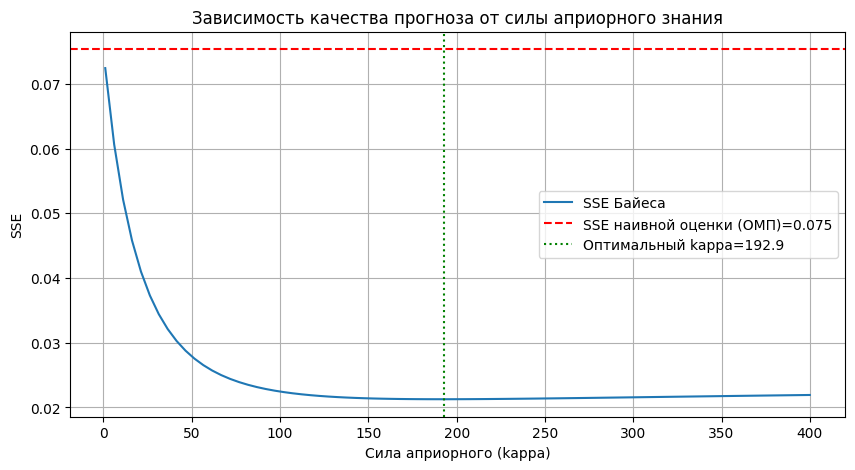

Оптимальное kappa: 192.92 (SSE=0.0213)


In [15]:
# 3.1 Качество прогноза (SSE) как функция силы априорного kappa

kappas = np.linspace(1, 400, 80)
m_prior = df.y.mean()
sse_list = []

# ==== ВАШ КОД ====

# для каждого kappa: alpha,beta = mk_to_ab(m_prior, kappa);
#                    est = bayes_estimate(df.r.values, N_AB, alpha, beta);
#                    sse = сумма квадратов (est - p)

for kappa in kappas:
    alpha, beta = mk_to_ab(m_prior, kappa)
    est = bayes_estimate(df.r.values, N_AB, alpha, beta)
    sse = np.sum((est - p)**2)
    sse_list.append(sse)

# соберите массив sse_list, постройте sse_list vs kappa,

min_sse = min(sse_list)
best_kappa = kappas[np.argmin(sse_list)]

# отметьте горизонталью SSE наивной оценки и найдите kappa с минимальным SSE

plt.figure(figsize=(10, 5))
plt.plot(kappas, sse_list, label='SSE Байеса')
plt.axhline(sse_naive, color='r', linestyle='--', label=f'SSE наивной оценки (ОМП)={sse_naive:.3f}')
plt.axvline(best_kappa, color='g', linestyle=':', label=f'Оптимальный kappa={best_kappa:.1f}')
plt.xlabel('Сила априорного (kappa)')
plt.ylabel('SSE')
plt.legend()
plt.title('Зависимость качества прогноза от силы априорного знания')
plt.grid(True)
plt.show()

print(f"Оптимальное kappa: {best_kappa:.2f} (SSE={min_sse:.4f})")

# =================

**Задание 3.2.** *(0.5 баллов)* Опишите форму кривой: что происходит при очень малом $\kappa$ (слабое
априорное) и очень большом $\kappa$ (слишком сильное)? Почему оптимум посередине?

*Ваш вывод:* `При очень малом k (слева): Байесовская оценка почти не сжимает результаты. Модель слепо доверяет сырым данным (ОМП), которые при малом количестве подач (всего 45) содержат много случайного шума. Ошибка велика, так как мы принимаем случайные удачи или неудачи за реальное мастерство игрока.

При очень большом k (справа): Модель слишком сильно доверяет априорному знанию. Всех игроков (независимо от их таланта) принудительно подтягивает к среднему по лиге. Индивидуальные различия стираются, и мы начинаем сильно ошибаться в прогнозе для тех, кто реально сильнее или слабее среднего. Это вносит систематическое искажение.

Почему оптимум посередине: Это баланс смещения и дисперсии. В этой точке модель достаточно гибкая, чтобы учитывать реальные таланты игроков, но при этом достаточно осторожная, чтобы отсекать случайные выбросы за счет среднего по лиге.`

**Задание 3.3.** *(1 балл)*

Возьмём одного игрока (Клементе, ранняя доля 0.4) и посмотрим, как байесовская оценка
приближается к ОМП по мере того, как у игрока становится больше подач (имитируем рост $n$ при той
же доле попаданий 0.4). Это численная иллюстрация теоремы об асимптотике из 3.1.

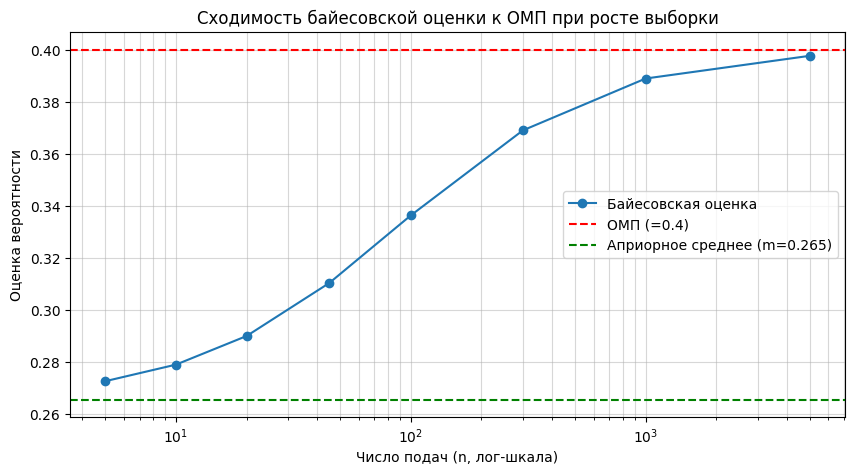

In [17]:
# 3.3 Байесовская оценка -> ОМП при росте n (доля попаданий фиксирована = 0.4)

ns = np.array([5, 10, 20, 45, 100, 300, 1000, 5000])
true_rate = 0.40
alpha0, beta0 = mk_to_ab(df.y.mean(), 90.0)

# ==== ВАШ КОД ====

# для каждого n: r = round(true_rate * n);  оценка = bayes_estimate(r, n, alpha0, beta0)

estimates = []
for n in ns:
    r = round(true_rate * n)
    est = bayes_estimate(r, n, alpha0, beta0)
    estimates.append(est)

# постройте оценку vs n (лог-шкала по x), отметьте горизонталью ОМП = true_rate
# и горизонталью априорное среднее

plt.figure(figsize=(10, 5))
plt.semilogx(ns, estimates, marker='o', label='Байесовская оценка')
plt.axhline(true_rate, color='r', linestyle='--', label=f'ОМП (={true_rate})')
plt.axhline(m_prior, color='g', linestyle='--', label=f'Априорное среднее (m={m_prior:.3f})')

plt.xlabel('Число подач (n, лог-шкала)')
plt.ylabel('Оценка вероятности')
plt.title('Сходимость байесовской оценки к ОМП при росте выборки')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

# =================

**Задание 3.4.** *(0.5 баллов)* При малом $n$ оценка ближе к ОМП или к априорному среднему?
А при большом $n$? Подтверждает ли график вашу теоретическую выкладку из 3.1?


*Ваш вывод:* `При малом n (слева): Оценка находится значительно ближе к априорному среднему (m=0.265), чем к ОМП (0.4). Это происходит потому, что сила априорного знания (k=90) доминирует над малым количеством реальных данных. Априорное знание выступает якорем, не позволяя модели улететь к крайнему значению из-за случайного шума.

При большом n (справа): Оценка стремится к ОМП (0.4). По мере роста количества наблюдений вес реальных данных становится подавляющим, и априорное влияние постепенно сходит на нет. При n=5000 байесовская оценка практически сливается с линией ОМП.

График подтверждает теорию:При малом n оценка стопарится у априорного среднего (0.265), защищая нас от случайных выбросов в данных.При росте n байесовская оценка неизбежно сходится к ОМП (0.4).`

## Часть 4. Байесовский доверительный (credible) интервал *(1.5 баллов)*

 У байесовской статистики есть свой аналог доверительных интервалов —
**байесовский (credible) интервал**: интервал, в который параметр попадает с заданной апостериорной вероятностью.



**Задание 4.1.**  *(1 балл)*
1. Дайте определение $(1-\alpha)$-**байесовского интервала** $[L, U]$ через апостериорное распределение:
$\mathbb P(\theta \in [L,U] \mid r) = 1-\alpha$. Для равнохвостого варианта $L$ и $U$ — это
квантили уровней $\gamma/2$ и $1-\gamma/2$ апостериорного $\mathrm{Beta}(\alpha+r,\ \beta+n-r)$.
2. Объясните **разницу** байесовского интервала и частотного доверительного интервала. Почему байесовская трактовка позволяет говорить  «параметр лежит
в этом интервале с вероятностью 0.95»?

*Ваш вывод:* `

1. В файле.

2. Разница в трактовке вероятности:

Частотный интервал: Параметр — константа, интервал — случайный. Мы говорим о вероятности того, что метод сработает в 95% случаев при повторении опыта. Говорить, что параметр в этом конкретном интервале с вероятностью 0.95, нельзя.

Байесовский интервал: Параметр — случайная величина (есть апостериорное распределение). Мы буквально измеряем площадь под графиком вероятностей. Поэтому мы имеем полное право сказать, чтопараметр с вероятностью 0.95 лежит здесь, так как это вероятность для самого параметра.

Итого: в байесовском подходе мы считаем правдой само распределение параметра, поэтому можем оценивать его вероятность напрямую. В частотном — мы лишь оцениваем надежность алгоритма построения интервалов.`

In [23]:
# 4.1 Равнохвостый 95% credible-интервал из апостериорного Beta

def credible_interval(r, n, alpha, beta, gamma=0.05):
    """Возвращает (L, U) — квантили gamma/2 и 1-gamma/2 апостериорного Beta(alpha+r, beta+n-r)."""

    # ==== ВАШ КОД ====

    # используйте stats.beta.ppf с параметрами (alpha+r) и (beta+n-r)

    L = stats.beta.ppf(gamma / 2, alpha + r, beta + n - r)
    U = stats.beta.ppf(1 - gamma / 2, alpha + r, beta + n - r)

    return L, U

    # =================

# для каждого игрока: точечная байесовская оценка + 95% credible-интервал

alpha0, beta0 = mk_to_ab(df.y.mean(), 90.0)

for i in [0, 16, 17]:                  # Клементе, Мансон, Макс Алвис
    L, U = credible_interval(df.r[i], N_AB, alpha0, beta0)
    print(f"{df.name[i]:18s} байесовская оценка={df.bayes[i]:.3f}, 95% CI=[{L:.3f}, {U:.3f}], истина p={df.p[i]:.3f}")

Roberto Clemente   байесовская оценка=0.310, 95% CI=[0.235, 0.391], истина p=0.346
Thurman Munson     байесовская оценка=0.236, 95% CI=[0.169, 0.311], истина p=0.316
Max Alvis          байесовская оценка=0.229, 95% CI=[0.162, 0.303], истина p=0.200


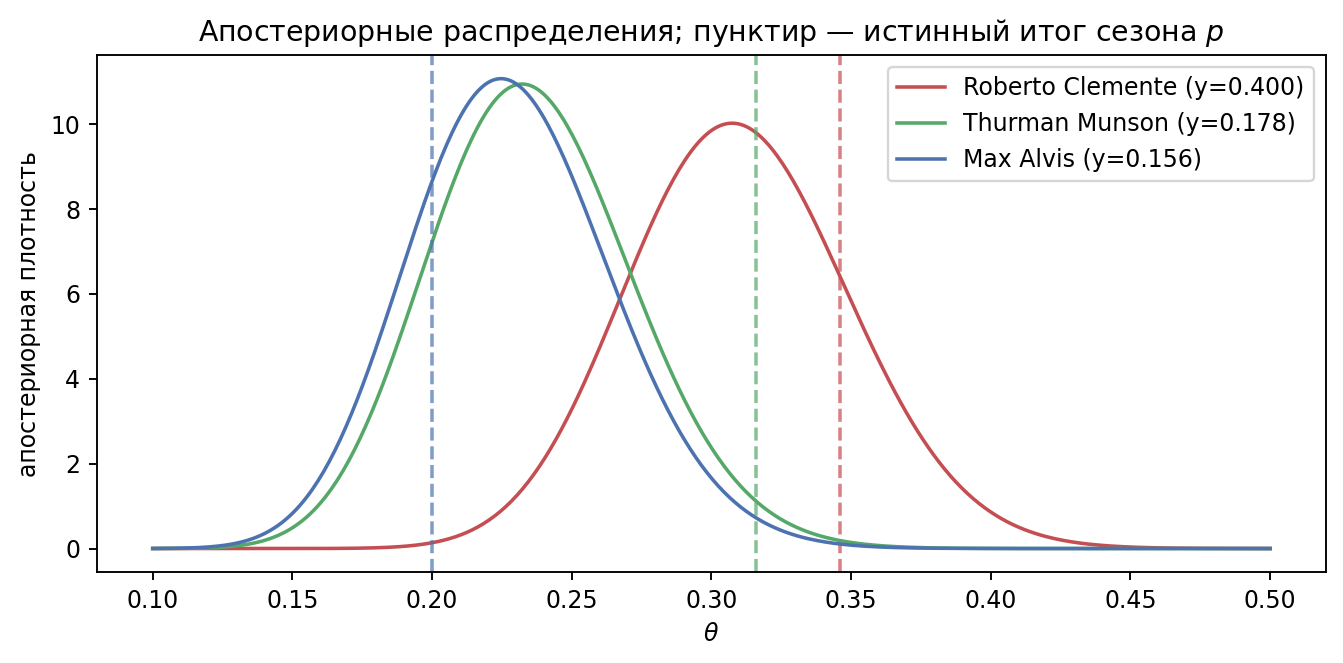

In [22]:
# (дано) Картинка: апостериорные плотности и credible-интервалы для трёх игроков

alpha0, beta0 = mk_to_ab(df.y.mean(), 90.0)

grid = np.linspace(0.1, 0.5, 400)

plt.figure(figsize=(8,4), dpi=170)

for i, col in zip([0, 16, 17], ["#C44E52", "#55A868", "#4C72B0"]):
    post = stats.beta.pdf(grid, alpha0 + df.r[i], beta0 + N_AB - df.r[i])
    plt.plot(grid, post, color=col, label=f"{df.name[i]} (y={df.y[i]:.3f})")
    plt.axvline(df.p[i], color=col, ls="--", alpha=0.7)
plt.xlabel(r"$\theta$"); plt.ylabel("апостериорная плотность")
plt.title("Апостериорные распределения; пунктир — истинный итог сезона $p$")
plt.legend(); plt.tight_layout(); plt.show()

**Задание 4.2.** *(0.5 баллов)* Накрывают ли credible-интервалы истинные `p`? Сравните ширину
credible-интервала с наивным частотным интервалом для Клементе $y \pm 1.96\sqrt{y(1-y)/45}$
(посчитайте его). Какой у́же и почему байесовский интервал не вылезает за разумные пределы?

*Ваш ответ:* `
1. Для Мансона интервал не накрыл истинное значение, так как результат оказался выше верхней границы. Это ничего такого : 95% доверительный интервал по определению допускает, что в 5% случаев истинное значение может оказаться за его пределами. У Алвиса и Клементе всё накрывается.

2. В файле.

3. Байесовский интервал базируется на Beta-распределении, которое определено строго на отрезке [0, 1]. Поэтому границы интервала математически не могут выйти за эти пределы. Частотный же интервал (через нормальную аппроксимацию) не имеет такой защит и при малых n может давать значения вероятности, выходящие за пределы [0, 1].
Байесовский интервал у́же частотного, потому что он работает с эффективной выборкой: к 45 реальным подачам добавляется 90 подач априорного опыта. Увеличение объема данных с 45 до 135 снижает дисперсию (неопределенность), что делает интервал точнее.
`

## Часть 5. Другие функции потерь *(1 балл)*

Байесовская оценка зависит от функции потерь. Для квадратичной функции потерь — это апостериорное среднее.



**Задание 5.1.** *(0.5 баллов)*
При абсолютной функции потерь $\rho(\theta,\widehat\theta)=|\theta-\widehat\theta|$
байесовская оценка — это **медиана** апостериорного распределения. Для нашего игрока апостериорное —
$\mathrm{Beta}(\alpha+r,\ \beta+n-r)$.

Объясните, почему медиана минимизирует ожидаемые абсолютные потери. Будет ли байесовская оценка при абсолютных потерях в нашем случае совпадать с оценкой при
квадратичных потерях? (подсказка: симметрично ли бета-распределение?)

*Ваш вывод:* `
1. Абсолютная функция потерь $\rho(\theta, \hat{\theta}) = |\theta - \hat{\theta}|$ минимизируется значением, которое делит распределение пополам. Если мы выберем $\hat{\theta}$ < medianа, то при смещении вправо мы уменьшаем ошибку для большей части площади под графиком. Если $\hat{\theta}$ > medianа — наоборот. Точка равновесия, где ошибка минимизируется, — это медиана апостериорного распределения.

2. При квадратичных потерях оценка — это среднее (математическое ожидание, писала в предыдущих номерах: альфа+эр делить на альфа+бэта+эн).При абсолютных потерях оценка — это медиана .Они не будут совпадать, если распределение асимметрично. А Beta-распределение симметрично только при альфа+эр = альфа+бэта-эр. В нашем случае (реальные данные игроков) распределения почти всегда асимметричны (скошены), так как количество удач r и неудач n-r редко идеально сбалансировано с учетом априора. Соотеветственно, среднее и медиана будут отличаться: при положительной скошенности среднее обычно правее медианы.
`

In [24]:
# 5.1 Сравнение байес-оценок при квадратичных  и абсолютных потерях
alpha0, beta0 = mk_to_ab(df.y.mean(), 90.0)

def bayes_median(r, n, alpha, beta):
    """Медиана апостериорного Beta."""

    # ==== ВАШ КОД ====

    # stats.beta.median(alpha+r, beta+n-r)  (или ppf(0.5, ...))

    return stats.beta.median(alpha + r, beta + n - r)
    # =================

for i in [0, 16]:

    mean_est = bayes_estimate(df.r[i], N_AB, alpha0, beta0)
    med_est  = bayes_median(df.r[i], N_AB, alpha0, beta0)
    print(f"{df.name[i]:18s} среднее={mean_est:.4f}, медиана={med_est:.4f}, разница={abs(mean_est-med_est):.4f}")

Roberto Clemente   среднее=0.3103, медиана=0.3093, разница=0.0009
Thurman Munson     среднее=0.2362, медиана=0.2349, разница=0.0013


**Задание 5.2.** *(0.5 баллов)* Насколько различаются среднее и медиана апостериорного? О чём это говорит
(симметрично ли апостериорное при таких параметрах $\alpha+r$, $\beta+n-r$)? В каком случае разница была бы большой?

*Ваш ответ:* `
1. Разница: Она минимальна.
2. Это говорит о том, что апостериорное распределение близко к симметричному «колоколу».Почему так: Из-за большой «эффективной» выборки (реальные данные + априор kappa=90 дают сумму параметров примерно 225). Согласно центральной предельной теореме, при таких значениях Бета-распределение стремится к нормальному, где среднее и медиана практически совпадают.
3. Когда разница была бы большой: При малом количестве данных (n): Например, если игрок сыграл всего 3 матча, распределение прижимается к границам 0 или 1 и становится сильно скошенным.При слабом априоре (ка стремится к 0): Если мы не опираемся на опыт лиги, распределение остается широким и асимметричным, где среднее сильно тянется к длинному хвосту, а медиана остается ближе к пику.

Итог: Разница между средним и медианой - это индикатор асимметрии. Чем больше данных, тем симметричнее распределение и тем ближе эти показатели друг к другу.`



---
###  Итоговый вывод по всему заданию

Резюмируйте:
1) Почему «доверять первым 45 подачам» — плохая стратегия и как байесовская статистика это
исправляет;
2) Как связаны выбор априорного и степень сжатия;
3) Что происходит с байесовской статистикой при
большом объёме данных;
4) Чем байесовский интервал отличается от доверительного по интерпретации.

*Ваш ответ:* `
1. Почему «доверять 45 подачам» - плохая стратегия: Малая выборка полна случайного шума. Доверяя только ей, мы получаем огромную дисперсию и прыгающие оценки, которые часто далеки от реального мастерства игрока. Байесовский подход исправляет это, добавляя априорное знание (опыт лиги), которое стабилизирует оценку, не позволяя случайным успехам или провалам искажать картину.
2. Связь априорного и сжатия: Априорное распределение (ка=90) выступает как гравитация для данных. Чем сильнее априор (выше к), тем сильнее сжатие (регуляризация): оценка игрока смещается к среднему показателю лиги, а интервал неопределенности сужается. Мы сознательно жертвуем некоторой точностью (смещением) ради значительного уменьшения дисперсии.
3. Что происходит при большом объеме данных: По мере накопления реальных данных влияние априора постепенно размывается. Апостериорное распределение становится всё более узким и симметричным (стремится к нормальному), а вклад данных игрока начинает доминировать над априорным ожиданием. В пределе (при  эн к бесконечности) байесовская оценка совпадает с частотной.
4. Различия в интерпретации: Доверительный интервал (частотный): Это не про конкретного игрока, а про процедуру. Если мы повторим эксперимент 100 раз, в 95 из них интервал накроет истинное значение. Байесовский интервал: Дает интуитивно понятный ответ: «С вероятностью 95% истинное мастерство этого конкретного игрока находится внутри данного диапазона». Он напрямую отражает нашу степень уверенности в параметре.`